 # 05 — Cartes LDCM (Local Dependability Confidence Maps)
### - Coordonnées géographiques RÉELLES utilisées (pas standardisées)
###   → latitude ∈ [32°N, 42°N], longitude ∈ [-124°W, -114°W]
### - Contour approximatif de la Californie


In [ ]:

import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

from src.config import FIGURES_DIR

os.makedirs(FIGURES_DIR, exist_ok=True)



## 1. Chargement du fichier SDRloc (généré par notebook 04)

In [ ]:

df = pd.read_csv("../data/test_points_with_sdr.csv")
print(f"Shape : {df.shape}")
print(f"Colonnes : {list(df.columns)}")

# Récupération coordonnées géographiques réelles
# ── vérification critique ─────────────────────────────────
assert 'longitude' in df.columns and 'latitude' in df.columns, \
    "ERREUR : longitude/latitude absentes du CSV — relancer notebook 04"

lon_min, lon_max = df['longitude'].min(), df['longitude'].max()
lat_min, lat_max = df['latitude'].min(),  df['latitude'].max()

print(f"\nCooronnées vérifiées :")
print(f"  longitude : [{lon_min:.2f}, {lon_max:.2f}]  "
      f"{'✓ géographiques réelles' if lon_min < -100 else '⚠ SEMBLENT STANDARDISÉES'}")
print(f"  latitude  : [{lat_min:.2f}, {lat_max:.2f}]  "
      f"{'✓ géographiques réelles' if lat_max > 30 else '⚠ SEMBLENT STANDARDISÉES'}")



Shape : (200, 21)
Colonnes : ['Unnamed: 0', 'longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN', 'SDRloc_RF', 'SDRloc_XGB', 'A_RF', 'A_XGB', 'S_RF', 'S_XGB', 'K_RF', 'K_XGB']

Cooronnées vérifiées :
  longitude : [-122.78, -116.91]  ✓ géographiques réelles
  latitude  : [32.63, 40.51]  ✓ géographiques réelles


## 2. LDCM — XGBoost (California Housing)

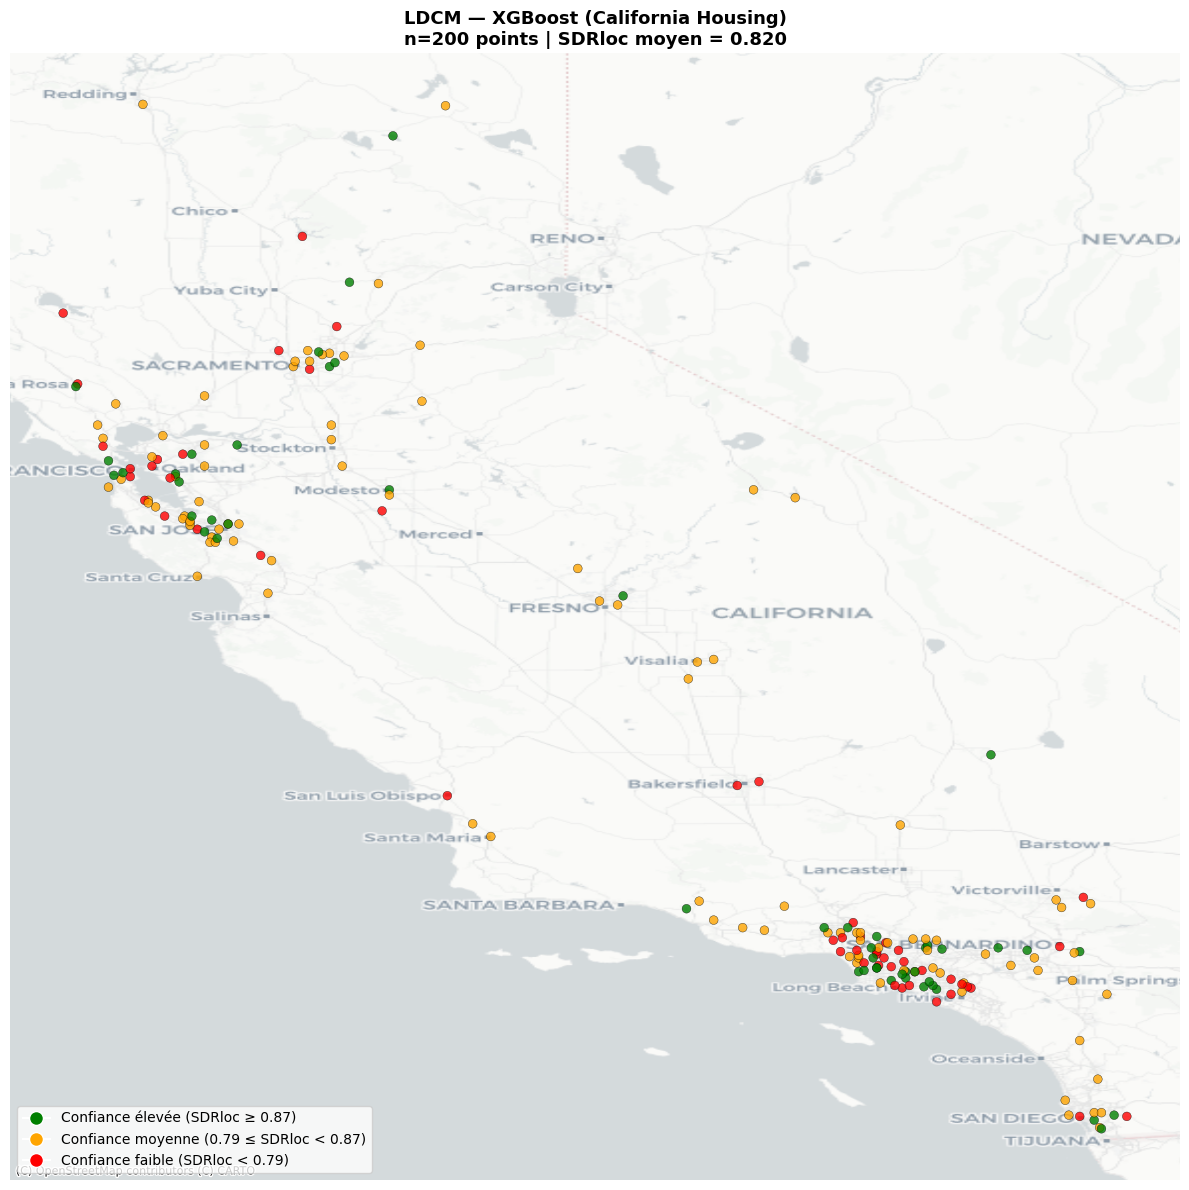

In [9]:
import numpy as np
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ============================================================
# 1. GeoDataFrame
# ============================================================
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.longitude, df.latitude),
    crs="EPSG:4326"
)

# Projection vers Web Mercator (obligatoire pour basemap)
gdf = gdf.to_crs(epsg=3857)

# ============================================================
# 2. Classification des couleurs selon SDRloc
# ============================================================
colors = np.where(
    gdf["SDRloc_XGB"] >= 0.87,
    "green",
    np.where(
        gdf["SDRloc_XGB"] >= 0.79,
        "orange",
        "red"
    )
)

# ============================================================
# 3. Figure
# ============================================================
fig, ax = plt.subplots(figsize=(12, 12))

ax.scatter(
    gdf.geometry.x,
    gdf.geometry.y,
    c=colors,
    s=40,
    alpha=0.8,
    edgecolors="k",
    linewidth=0.3
)

# ============================================================
# 4. Fond de carte (California basemap)
# ============================================================
ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron
)

# ============================================================
# 5. Légende personnalisée
# ============================================================
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='green', markersize=10,
           label='Confiance élevée (SDRloc ≥ 0.87)'),

    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='orange', markersize=10,
           label='Confiance moyenne (0.79 ≤ SDRloc < 0.87)'),

    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='red', markersize=10,
           label='Confiance faible (SDRloc < 0.79)')
]

ax.legend(handles=legend_elements, loc='lower left')

# ============================================================
# 6. Mise en forme
# ============================================================
ax.set_title(
    "LDCM — XGBoost (California Housing)\n"
    f"n={len(df)} points | SDRloc moyen = {gdf['SDRloc_XGB'].mean():.3f}",
    fontsize=13,
    fontweight="bold"
)

ax.set_axis_off()
plt.tight_layout()

# ============================================================
# 7. Sauvegarde
# ============================================================
plt.savefig(
    f"{FIGURES_DIR}/ldcm_xgboost_map.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 3. LDCM — Random Forest (California Housing)

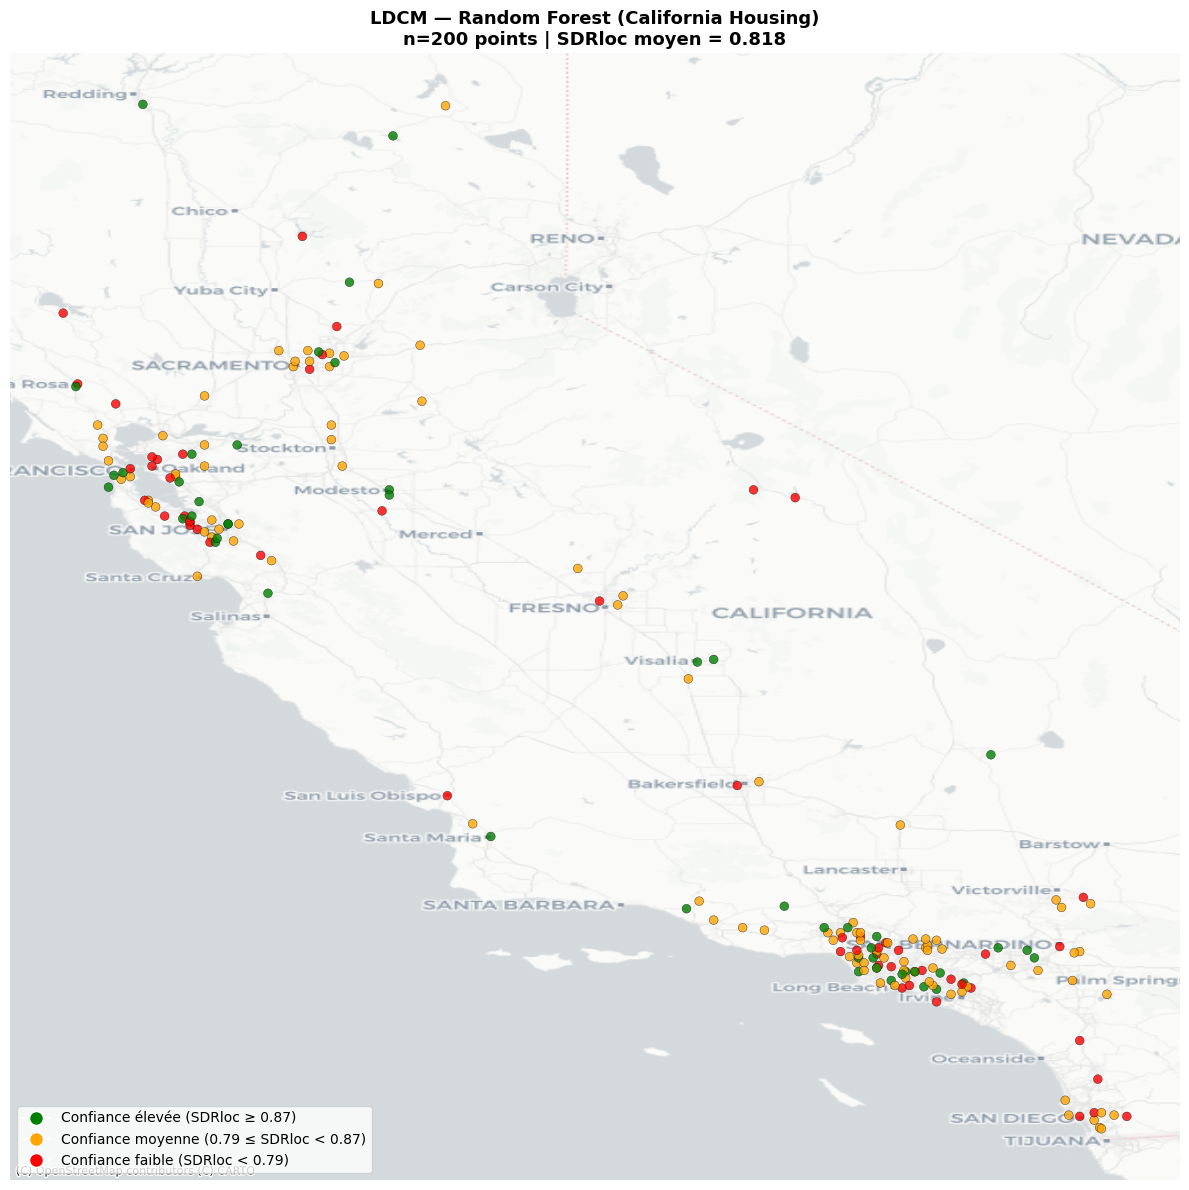

In [10]:
import numpy as np
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ============================================================
# GeoDataFrame
# ============================================================
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.longitude, df.latitude),
    crs="EPSG:4326"
)

gdf = gdf.to_crs(epsg=3857)

# ============================================================
# Seuils SDRloc
# ============================================================
colors = np.where(
    gdf["SDRloc_RF"] >= 0.87,
    "green",
    np.where(
        gdf["SDRloc_RF"] >= 0.79,
        "orange",
        "red"
    )
)

# ============================================================
# Figure
# ============================================================
fig, ax = plt.subplots(figsize=(12, 12))

ax.scatter(
    gdf.geometry.x,
    gdf.geometry.y,
    c=colors,
    s=40,
    alpha=0.8,
    edgecolors="k",
    linewidth=0.3
)

# ============================================================
# Basemap
# ============================================================
ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron
)

# ============================================================
# Légende
# ============================================================
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='green', markersize=10,
           label='Confiance élevée (SDRloc ≥ 0.87)'),

    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='orange', markersize=10,
           label='Confiance moyenne (0.79 ≤ SDRloc < 0.87)'),

    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='red', markersize=10,
           label='Confiance faible (SDRloc < 0.79)')
]

ax.legend(handles=legend_elements, loc='lower left')

# ============================================================
# Title
# ============================================================
ax.set_title(
    "LDCM — Random Forest (California Housing)\n"
    f"n={len(df)} points | SDRloc moyen = {gdf['SDRloc_RF'].mean():.3f}",
    fontsize=13,
    fontweight="bold"
)

ax.set_axis_off()
plt.tight_layout()

# ============================================================
# Save
# ============================================================
plt.savefig(
    f"{FIGURES_DIR}/ldcm_rf_map.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 4. Différence de confiance locale — XGBoost vs Random Forest

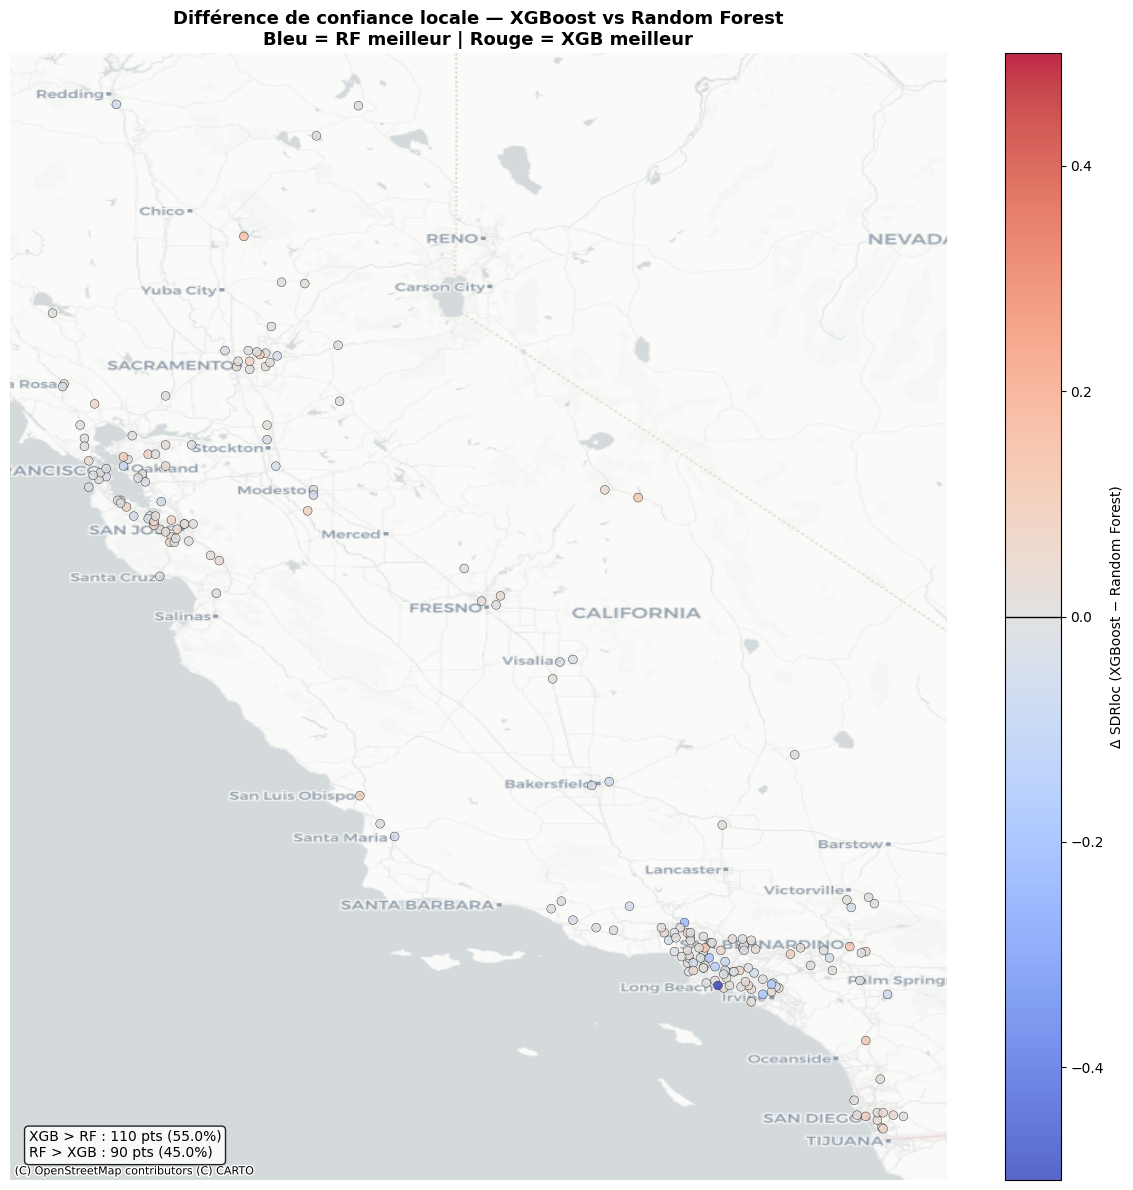

In [11]:
import numpy as np
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt

# ============================================================
# GeoDataFrame
# ============================================================
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.longitude, df.latitude),
    crs="EPSG:4326"
)

gdf = gdf.to_crs(epsg=3857)

# ============================================================
# Différence
# ============================================================
diff = gdf["SDRloc_XGB"] - gdf["SDRloc_RF"]

# ============================================================
# Figure
# ============================================================
fig, ax = plt.subplots(figsize=(12, 12))

sc = ax.scatter(
    gdf.geometry.x,
    gdf.geometry.y,
    c=diff,
    cmap="coolwarm",
    s=40,
    alpha=0.85,
    edgecolors="k",
    linewidth=0.3,
    vmin=-0.5,
    vmax=0.5
)

# ============================================================
# Basemap
# ============================================================
ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron
)

# ============================================================
# Colorbar
# ============================================================
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Δ SDRloc (XGBoost − Random Forest)")
cbar.ax.axhline(0, color="black", linewidth=1)

# ============================================================
# Stats globales
# ============================================================
n_xgb_better = (diff > 0).sum()
n_rf_better = (diff < 0).sum()

ax.text(
    0.02, 0.02,
    f"XGB > RF : {n_xgb_better} pts ({n_xgb_better/len(diff)*100:.1f}%)\n"
    f"RF > XGB : {n_rf_better} pts ({n_rf_better/len(diff)*100:.1f}%)",
    transform=ax.transAxes,
    fontsize=10,
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
)

# ============================================================
# Title
# ============================================================
ax.set_title(
    "Différence de confiance locale — XGBoost vs Random Forest\n"
    "Bleu = RF meilleur | Rouge = XGB meilleur",
    fontsize=13,
    fontweight="bold"
)

ax.set_axis_off()
plt.tight_layout()

# ============================================================
# Save
# ============================================================
plt.savefig(
    f"{FIGURES_DIR}/ldcm_diff_map.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 5. Décomposition du SDRloc — XGBoost (A, S, K)

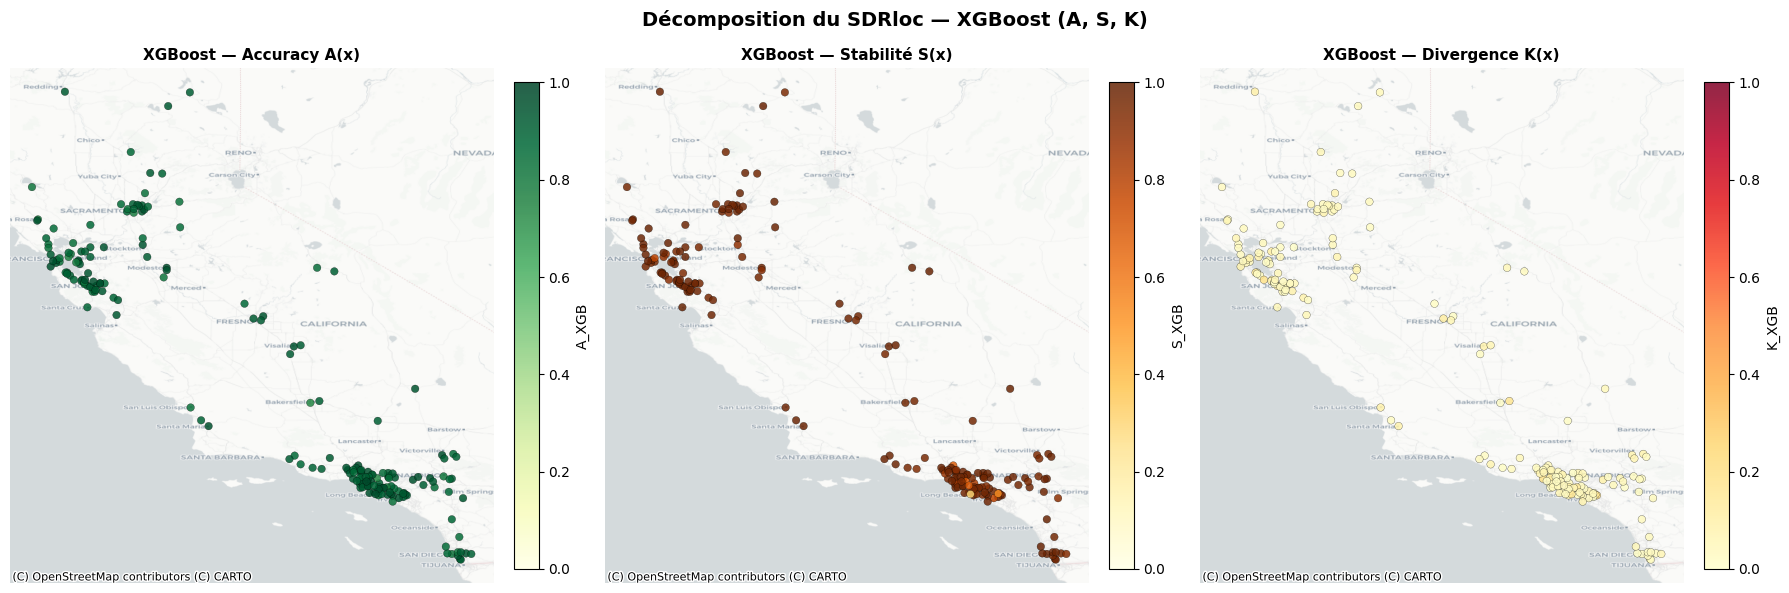

In [12]:
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt

# ============================================================
# GeoDataFrame
# ============================================================
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.longitude, df.latitude),
    crs="EPSG:4326"
)

gdf = gdf.to_crs(epsg=3857)

# ============================================================
# Vérification des composantes
# ============================================================
if all(c in gdf.columns for c in ['A_XGB', 'S_XGB', 'K_XGB']):

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    components = [
        ('A_XGB', 'Accuracy A(x)', 'YlGn'),
        ('S_XGB', 'Stabilité S(x)', 'YlOrBr'),
        ('K_XGB', 'Divergence K(x)', 'YlOrRd')
    ]

    for ax, (col, title, cmap) in zip(axes, components):

        sc = ax.scatter(
            gdf.geometry.x,
            gdf.geometry.y,
            c=gdf[col],
            cmap=cmap,
            s=30,
            alpha=0.85,
            edgecolors='k',
            linewidth=0.2,
            vmin=0,
            vmax=1
        )

        # Basemap
        ctx.add_basemap(
            ax,
            source=ctx.providers.CartoDB.Positron
        )

        # Colorbar
        cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label(col)

        ax.set_title(f"XGBoost — {title}", fontsize=11, fontweight='bold')
        ax.set_axis_off()

    plt.suptitle(
        "Décomposition du SDRloc — XGBoost (A, S, K)",
        fontsize=14,
        fontweight='bold'
    )

    plt.tight_layout()

    plt.savefig(
        f"{FIGURES_DIR}/ldcm_components_xgb.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()